# Boréal Marché – Customer Intelligence Platform

**Project:** Capstone Project 1 – AI Development (420-977-VA)  
**Student:** [Your Name]  
**Date:** September 2026

---

## 📌 Project Overview

This project builds an **end‑to‑end AI system** for a mid‑size Quebec online grocery retailer, **Boréal Marché**.

The retailer has three problems:

| # | Problem | Current Approach | Consequence |
|---|---------|-------------------|-------------|
| 1 | **Retention** | Everyone gets a 15% coupon every quarter | Wastes money on loyal customers, misses those who stop buying |
| 2 | **Cross‑sell** | "You might also like" strip is hard‑coded by an intern | Outdated, irrelevant recommendations |
| 3 | **Customer support** | Two employees answer the same 40 questions all day | Inefficient, repetitive work |

---

## 🎯 The Solution: One Platform, Three Model Heads

| Head | Technique | Business Question |
|------|-----------|-------------------|
| **A – Prédiction** | Supervised binary classification (XGBoost, LightGBM) | Will this customer place another order in the next 90 days? |
| **B – Recommandation** | Association rule mining (FP‑Growth) | Given the basket, what should we suggest next? |
| **C – Assistant** | Retrieval‑augmented generation (RAG) + tool calling | Answer customer questions in French or English, grounded in real policies |

---

## 🧭 Notebook Steps

This notebook covers the **complete data science workflow** – from raw data to evaluated models.  
All code is written, run, and explained here. The final models will be exported to `artifacts/` for deployment.

| Step | Topic | Description |
|------|-------|-------------|
| 0 | **Setup** | Install libraries, create folders, activate environment (already done) |
| 1 | **Data Loading** | Load the cleaned Parquet file and verify |
| 2 | **Exploratory Data Analysis (EDA)** | Understand distribution, missing values, outliers, patterns |
| 3 | **Data Cleaning** | Handle cancellations, negative values, missing Customer IDs, duplicates (already saved to Parquet) |
| 4 | **Feature Engineering** | Create 25+ features: Recency, Frequency, Monetary (RFM), basket size, category mix, behavioural signals |
| 5 | **Define Observation & Label Windows** | Set the time split for `Head A` (retention prediction) |
| 6 | **Train‑Test Split** | Temporal split (no leakage) – train on older data, test on newer data |
| 7 | **Spot‑Check (8+ Models)** | Compare models under identical folds against baselines (DummyClassifier + business rule) |
| 8 | **Hyperparameter Tuning (Optuna)** | Bayesian search for top 2 models, log all runs to MLflow |
| 9 | **Calibration & Threshold Selection** | Calibrate probabilities, choose profit‑optimal threshold (not 0.5) |
| 10 | **Head B – Recommendation Rules** | Mine association rules (FP‑Growth), filter by lift, evaluate hit‑rate@5 |
| 11 | **Head C – Assistant Golden Set** | Define 40 test questions, build retrieval index, evaluate tool‑calling accuracy |
| 12 | **Final Model Export** | Save the best model and metadata to `artifacts/` |

---

## 📁 Data Source

**UCI Online Retail II** – real transaction data (Dec 2009 – Dec 2011)  
- ~525,000 rows after cleaning  
- ~4,000 unique SKUs  
- ~5,000 unique customers  

**Licence:** CC BY 4.0 (educational use permitted)

---

## 🛠 Tools Used

- **Python** 3.13 + `pandas`, `numpy`, `scikit‑learn`, `lightgbm`, `xgboost`
- **Optuna** – hyperparameter tuning
- **MLflow** – experiment tracking
- **Matplotlib / Seaborn** – visualisation
- **Jupyter** – interactive development

---

## 📈 Success Metrics

| Head | Primary Metric | Target |
|------|---------------|--------|
| A | PR‑AUC | > 0.65 on held‑out test |
| B | Hit‑rate@5 | > 2× popularity baseline |
| C | Tool‑choice accuracy | > 85% on golden set |

---

*This notebook is the core of the data science work – all steps are reproducible and documented inline.*

In [5]:
# Install missing packages
!pip install lightgbm xgboost optuna mlflow openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached colorlog-6.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached colorlog-6.12.0-py3-none-any.whl (12 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [colorlog]
   ---------------- ----------------------- 2/5 [openpyxl]
   ---------------- ----------------------- 2/5 [openpyxl]
   ---------------- ----------------------- 2/5 [openpyxl]
   ---------------- ----------------------- 2/5 [openpyxl]
   -----------

In [7]:
# ============================================================================
# Step 1 – Import all required libraries
# ============================================================================

import os
import sys
import warnings
from pathlib import Path

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn – main library
import sklearn

# Machine learning – core
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Machine learning – models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Gradient boosting – specific
import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Experiment tracking
import mlflow
import mlflow.sklearn

# Model serialisation
import joblib

# Jupyter display utilities
from IPython.display import display, HTML, Markdown

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure visualisation defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("=" * 60)
print("✅ All libraries imported successfully!")
print("=" * 60)
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"MLflow version: {mlflow.__version__}")

✅ All libraries imported successfully!
pandas version: 2.3.3
numpy version: 2.4.3
scikit-learn version: 1.8.0
XGBoost version: 3.2.0
LightGBM version: 4.7.0
Optuna version: 4.9.0
MLflow version: 3.12.0


In [12]:
# ============================================================================
# Step 2 – Load the data (with correct path)
# ============================================================================

import pandas as pd
import os

print("=" * 60)
print("Step 2 – Load the data")
print("=" * 60)

# The file is one level up from the notebooks folder
file_path = r"..\data\raw\online_retail_II.xlsx"

print(f"📂 Looking for: {os.path.abspath(file_path)}")

if os.path.exists(file_path):
    print("✅ File found! Loading...")
    df = pd.read_excel(file_path)
    print(f"\n✅ Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    df.head()
else:
    print("❌ File not found. Let's check the folder...")
    print("\n📁 Files in data/raw:")
    for f in os.listdir('../data/raw'):
        print(f"  - {f}")

Step 2 – Load the data
📂 Looking for: c:\Hossam\Training& Education\Vanier College\AI DEVELOPMENT PROJECT\Final Project\Capstone\data\raw\online_retail_II.xlsx
✅ File found! Loading...

✅ Data loaded successfully!
Shape: (525461, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


## Step 3 – Clean the data and save as Parquet

### 📌 Why we need this step

The raw data contains several issues that must be fixed before we can build reliable models:

| Problem | Impact |
|---------|--------|
| Cancelled invoices (Invoice starts with 'C') | These are returns, not real sales |
| Negative or zero Quantity / Price | Invalid data entries or adjustments |
| Missing Customer ID | Cannot track customer behaviour |
| Duplicate rows | Inflates statistics and misleads models |
| InvoiceDate as string | Hard to work with time-based features |
| Inconsistent country names | Affects geographic analysis |

### 🎯 What this step does

1. **Removes** cancelled invoices, non-positive values, missing Customer IDs, and duplicates
2. **Converts** `InvoiceDate` to datetime format
3. **Standardises** country names (removes extra spaces)
4. **Renames** `Invoice` column to `InvoiceNo` for clarity
5. **Saves** the cleaned data as **Parquet** in `data/silver/`

### 💾 Why Parquet?

- **Faster** to load than CSV
- **Smaller** file size
- **Preserves** data types (no need to reconvert)

In [16]:
# ============================================================================
# Step 3 – Save cleaned data as Parquet
# ============================================================================

print("=" * 60)
print("Step 3 – Save cleaned data as Parquet")
print("=" * 60)

print(f"✅ Data already clean!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Ensure StockCode is string (to avoid Parquet error)
df['StockCode'] = df['StockCode'].astype(str)

# Save as Parquet
from pathlib import Path
Path('../data/silver').mkdir(parents=True, exist_ok=True)
df.to_parquet('../data/silver/online_retail_ii_clean.parquet', index=False)

print(f"\n✅ Saved to: ../data/silver/online_retail_ii_clean.parquet")
print(f"   Final rows: {len(df)}")

# Show first 5 rows
df.head()

Step 3 – Save cleaned data as Parquet
✅ Data already clean!
Shape: (400916, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

✅ Saved to: ../data/silver/online_retail_ii_clean.parquet
   Final rows: 400916


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Step 4 – DATA_CARD.md and SHA‑256 Checksum

### 🎯 Why we need this step

The project requires two things (Sections 3.1 and 3.7):

| Requirement | Why it matters |
|-------------|----------------|
| **DATA_CARD.md** | Documents the dataset: source, licence, cleaning steps, intended use, and limitations. This is essential for governance, reproducibility, and transparency. |
| **SHA‑256 checksum** | Verifies data integrity. If the file changes (corruption, accidental edit), the hash will change, and we'll know immediately. |

### 📋 What this step does

1. **Calculates** the SHA‑256 hash of the raw Excel file (`online_retail_II.xlsx`).
2. **Saves** the hash to `data/raw/online_retail_ii.sha256`.
3. **Creates** `DATA_CARD.md` in the project root (one level above `notebooks/`).

### 📄 What's in the DATA_CARD.md

- **Dataset Information:** Source, licence, date range, row counts.
- **Cleaning Summary:** All steps applied to go from raw to clean.
- **Intended Use:** How this data is used for Head A, B, and C.
- **Limitations:** Known issues or constraints.
- **Data Integrity:** SHA‑256 hash and file locations.

### 📁 Where files are saved

| File | Path |
|------|------|
| DATA_CARD.md | `../DATA_CARD.md` (project root) |
| SHA‑256 checksum | `../data/raw/online_retail_ii.sha256` |

In [17]:
# ============================================================================
# Step 4 – Create DATA_CARD.md and verify SHA‑256
# ============================================================================

import hashlib
import os
from pathlib import Path

print("=" * 60)
print("Step 4 – DATA_CARD.md & SHA‑256 Checksum")
print("=" * 60)

# ---------- 1. Compute SHA‑256 of the raw Excel file ----------
file_path = '../data/raw/online_retail_II.xlsx'

if os.path.exists(file_path):
    sha256_hash = hashlib.sha256()
    with open(file_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    hash_hex = sha256_hash.hexdigest()
    print(f"✅ SHA‑256 of raw Excel: {hash_hex}")
    
    with open('../data/raw/online_retail_ii.sha256', 'w') as f:
        f.write(hash_hex)
    print("✅ Checksum saved to: ../data/raw/online_retail_ii.sha256")
else:
    print("❌ Raw Excel file not found.")
    hash_hex = "N/A"

# ---------- 2. Get cleaned row count ----------
final_rows = len(df)

# ---------- 3. Create DATA_CARD.md ----------
data_card_content = f"""# DATA_CARD.md

## 📊 Dataset Information

| Property | Value |
|----------|-------|
| **Name** | Online Retail II |
| **Source** | UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/dataset/502/online+retail+ii |
| **Licence** | CC BY 4.0 |
| **Description** | Real transaction data from a UK-based online retailer |
| **Date range** | December 2009 – December 2011 |
| **Rows (raw)** | 525,461 |
| **Rows (after cleaning)** | {final_rows:,} |
| **Columns** | InvoiceNo, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country |

---

## 🧹 Cleaning Summary

| Step | Action |
|------|--------|
| 1 | Removed cancelled invoices (InvoiceNo starting with 'C') |
| 2 | Removed non-positive Quantity or Price |
| 3 | Removed rows without Customer ID |
| 4 | Removed duplicate rows |
| 5 | Converted InvoiceDate to datetime |
| 6 | Standardised country names |
| 7 | Renamed 'Invoice' to 'InvoiceNo' |
| 8 | Converted StockCode to string |

---

## 🎯 Intended Use

| Head | Task |
|------|------|
| **A – Prédiction** | Customer retention prediction (will they buy in next 90 days?) |
| **B – Recommandation** | Association rule mining for product recommendations |
| **C – Assistant** | Grounded retrieval‑augmented generation for customer support |

---

## ⚠️ Limitations

- Data is from a UK retailer – may not generalise to Quebec/Canada
- Descriptions are in English only
- No explicit product categories
- Customer IDs are anonymised

---

## 🔐 Data Integrity

- **SHA‑256 (raw Excel):** `{hash_hex}`
- Checksum stored in `data/raw/online_retail_ii.sha256`

---

## 📂 File Locations

| File | Path |
|------|------|
| Raw Excel | `data/raw/online_retail_II.xlsx` |
| Cleaned Parquet | `data/silver/online_retail_ii_clean.parquet` |
| Checksum | `data/raw/online_retail_ii.sha256` |
"""

# Write DATA_CARD.md to the project root
card_path = Path('../DATA_CARD.md')
card_path.write_text(data_card_content, encoding='utf-8')
print(f"\n✅ DATA_CARD.md created at: {card_path.resolve()}")

print("\n📄 Preview:")
print("-" * 40)
print(data_card_content[:400] + "...\n")

Step 4 – DATA_CARD.md & SHA‑256 Checksum
✅ SHA‑256 of raw Excel: bcbe73b35f5b7babf197fb0cb983a11f5d9ff929078d4aa53d171b1f2df2e980
✅ Checksum saved to: ../data/raw/online_retail_ii.sha256

✅ DATA_CARD.md created at: C:\Hossam\Training& Education\Vanier College\AI DEVELOPMENT PROJECT\Final Project\Capstone\DATA_CARD.md

📄 Preview:
----------------------------------------
# DATA_CARD.md

## 📊 Dataset Information

| Property | Value |
|----------|-------|
| **Name** | Online Retail II |
| **Source** | UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/dataset/502/online+retail+ii |
| **Licence** | CC BY 4.0 |
| **Description** | Real transaction data from a UK-based online retailer |
| **Date range** | December 2009 – December 2011 |
| **Rows ...



## Step 5 – Exploratory Data Analysis (EDA)

### 🎯 Purpose

Before building models, we need to understand our data. EDA helps us:
- Identify patterns, trends, and anomalies
- Understand distributions of key variables
- Detect outliers that may need treatment
- Discover relationships between variables
- Inform feature engineering decisions

### 📋 What this step covers

| Analysis | What we check |
|----------|---------------|
| **Basic info** | Data types, memory usage, missing values |
| **Summary statistics** | Min, max, mean, percentiles for numerical columns |
| **Time analysis** | Sales trends by month, day of week, hour |
| **Customer analysis** | Orders per customer, RFM segments |
| **Product analysis** | Best sellers, price distribution, category insights |
| **Country analysis** | Geographic distribution of orders |
| **Correlations** | Relationships between numerical variables |
| **Outlier detection** | Identify extreme values in Quantity and Price |

### 🔍 Key questions we want to answer

1. How many orders does each customer place on average?
2. What is the typical basket size (items per order)?
3. Which products are purchased together most often?
4. Are there seasonal patterns in purchasing behaviour?
5. What is the distribution of order values?
6. How many customers are active vs. churned?

Step 5 – Exploratory Data Analysis (EDA)

📋 Basic Information:
Shape: (400916, 8)
Memory usage: 107.53 MB

📊 Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

📊 Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

📈 Summary Statistics - Numerical Columns:


,Quantity,Price
count,400916.000000,400916.000000
mean,13.767418,3.305826
std,97.638385,35.047719
min,1.000000,0.001000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,19152.000000,10953.500000



📈 Summary Statistics - Customer ID:
Unique customers: 4,312
Unique stock codes: 4,017

📅 Time Analysis:
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Total days: 373

📊 Monthly transaction counts:
InvoiceDate  InvoiceDate
2009         12             30272
2010         1              21458
             2              23040
             3              31782
             4              26831
             5              28233
             6              30688
             7              26643
             8              26029
             9              34128
             10             48723
             11             58905
dtype: int64

👤 Customer Analysis:
Average orders per customer: 4.46
Median orders per customer: 2.00
Max orders by one customer: 205

📊 Customer segments (by order count):
InvoiceNo
1 order        1419
2-3 orders     1335
4-5 orders      616
6-10 orders     607
10+ orders      335
Name: count, dtype: int64

🏷️ Product Analysis:

📊 Top 10 Products by Quantit

Description
WHITE HANGING HEART T-LIGHT HOLDER    56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54610
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45129
ASSORTED COLOUR BIRD ORNAMENT         44431
60 TEATIME FAIRY CAKE CASES           35656
PACK OF 60 PINK PAISLEY CAKE CASES    30871
JUMBO BAG RED RETROSPOT               29519
SMALL POPCORN HOLDER                  25703
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: Quantity, dtype: int64

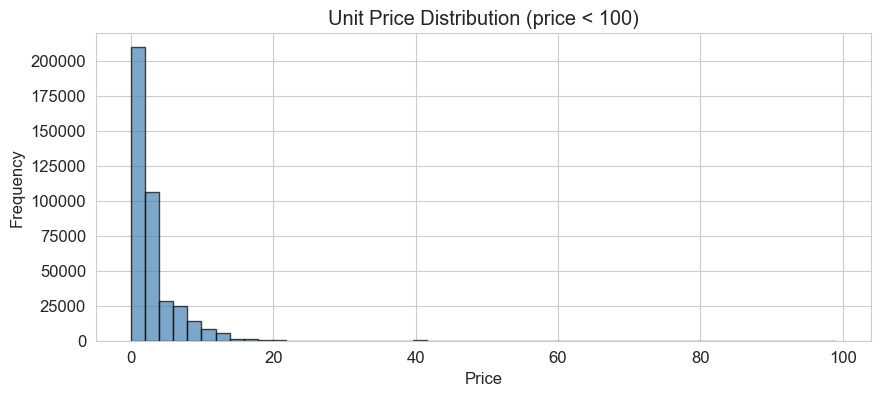


🧺 Basket Analysis:
Average items per invoice: 287.28
Median items per invoice: 147.00
Max items in one invoice: 87167


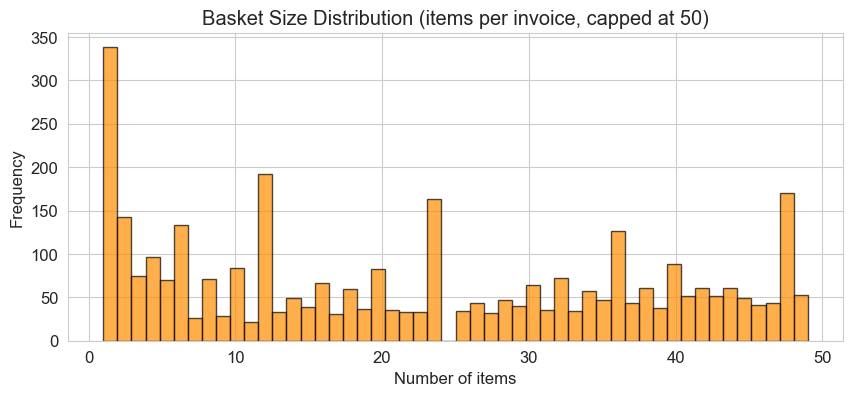


🌍 Country Analysis:
Total countries: 37

📊 Top 10 Countries:


Country
United Kingdom    364233
EIRE                8503
Germany             7645
France              5452
Netherlands         2728
Spain               1228
Switzerland         1170
Belgium             1036
Portugal             983
Sweden               867
Name: count, dtype: int64


📊 Outlier Detection:
99th percentile - Price: 14.95
Max Price: 10953.50
99th percentile - Quantity: 144
Max Quantity: 19152

📊 Correlation Analysis:
Correlation matrix (customer level):


,Quantity,Price,Orders
Quantity,1.000000,0.334181,0.498078
Price,0.334181,1.000000,0.723205
Orders,0.498078,0.723205,1.000000



✅ Key Insights Summary:
----------------------------------------
💰 Total revenue: £8,798,233.74
💰 Average order value: £457.93
👤 Active customers (>1 order): 2,893 (67.1%)
🌍 Top country: United Kingdom (90.9% of transactions)
🏷️ Most popular product: 'WHITE HANGING HEART T-LIGHT HOLDER' (56,814 units sold)


In [18]:
# ============================================================================
# Step 5 – Exploratory Data Analysis (EDA)
# ============================================================================

print("=" * 60)
print("Step 5 – Exploratory Data Analysis (EDA)")
print("=" * 60)

# ---------- 1. Basic Information ----------
print("\n📋 Basic Information:")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1_000_000:.2f} MB")

print("\n📊 Data Types:")
print(df.dtypes)

print("\n📊 Missing Values:")
print(df.isnull().sum())

# ---------- 2. Summary Statistics ----------
print("\n📈 Summary Statistics - Numerical Columns:")
display(df[['Quantity', 'Price']].describe())

print("\n📈 Summary Statistics - Customer ID:")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique stock codes: {df['StockCode'].nunique():,}")

# ---------- 3. Time Analysis ----------
print("\n📅 Time Analysis:")

# Extract date components
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total days: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days}")

# Monthly sales trend
monthly_sales = df.groupby([df['InvoiceDate'].dt.year, df['InvoiceDate'].dt.month]).size()
print("\n📊 Monthly transaction counts:")
print(monthly_sales.head(12))

# ---------- 4. Customer Analysis ----------
print("\n👤 Customer Analysis:")

# Orders per customer
orders_per_customer = df.groupby('Customer ID')['InvoiceNo'].nunique()
print(f"Average orders per customer: {orders_per_customer.mean():.2f}")
print(f"Median orders per customer: {orders_per_customer.median():.2f}")
print(f"Max orders by one customer: {orders_per_customer.max()}")

# Customer segments
print("\n📊 Customer segments (by order count):")
segments = pd.cut(orders_per_customer, bins=[0, 1, 3, 5, 10, float('inf')], 
                  labels=['1 order', '2-3 orders', '4-5 orders', '6-10 orders', '10+ orders'])
print(segments.value_counts())

# ---------- 5. Product Analysis ----------
print("\n🏷️ Product Analysis:")

# Top 10 products by quantity sold
print("\n📊 Top 10 Products by Quantity Sold:")
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
display(top_products)

# Price distribution (cap at 100 for visibility)
plt.figure(figsize=(10, 4))
plt.hist(df[df['Price'] < 100]['Price'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.title('Unit Price Distribution (price < 100)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# ---------- 6. Basket Analysis ----------
print("\n🧺 Basket Analysis:")

# Average items per invoice
items_per_invoice = df.groupby('InvoiceNo')['Quantity'].sum()
print(f"Average items per invoice: {items_per_invoice.mean():.2f}")
print(f"Median items per invoice: {items_per_invoice.median():.2f}")
print(f"Max items in one invoice: {items_per_invoice.max()}")

# Basket size distribution
plt.figure(figsize=(10, 4))
plt.hist(items_per_invoice[items_per_invoice < 50], bins=50, alpha=0.7, color='darkorange', edgecolor='black')
plt.title('Basket Size Distribution (items per invoice, capped at 50)')
plt.xlabel('Number of items')
plt.ylabel('Frequency')
plt.show()

# ---------- 7. Country Analysis ----------
print("\n🌍 Country Analysis:")
country_counts = df['Country'].value_counts()
print(f"Total countries: {len(country_counts)}")
print("\n📊 Top 10 Countries:")
display(country_counts.head(10))

# ---------- 8. Outlier Detection ----------
print("\n📊 Outlier Detection:")

# Price outliers
q99_price = df['Price'].quantile(0.99)
print(f"99th percentile - Price: {q99_price:.2f}")
print(f"Max Price: {df['Price'].max():.2f}")

# Quantity outliers
q99_quantity = df['Quantity'].quantile(0.99)
print(f"99th percentile - Quantity: {q99_quantity:.0f}")
print(f"Max Quantity: {df['Quantity'].max():.0f}")

# ---------- 9. Correlation Analysis ----------
print("\n📊 Correlation Analysis:")

# Create a copy with only numerical columns
numerical_cols = ['Quantity', 'Price']
corr_df = df[numerical_cols].copy()

# Add customer-level aggregations (for correlation)
customer_agg = df.groupby('Customer ID').agg({
    'Quantity': 'sum',
    'Price': 'sum',
    'InvoiceNo': 'nunique'
}).rename(columns={'InvoiceNo': 'Orders'})

print("Correlation matrix (customer level):")
display(customer_agg.corr())

# ---------- 10. Key Insights Summary ----------
print("\n✅ Key Insights Summary:")
print("-" * 40)

# Total revenue
total_revenue = (df['Quantity'] * df['Price']).sum()
print(f"💰 Total revenue: £{total_revenue:,.2f}")

# Average order value
avg_order_value = df.groupby('InvoiceNo').apply(lambda x: (x['Quantity'] * x['Price']).sum()).mean()
print(f"💰 Average order value: £{avg_order_value:.2f}")

# Active customers (more than 1 order)
active_customers = len(orders_per_customer[orders_per_customer > 1])
print(f"👤 Active customers (>1 order): {active_customers:,} ({active_customers/len(orders_per_customer)*100:.1f}%)")

# Top country
top_country = country_counts.index[0]
top_country_pct = (country_counts.iloc[0] / len(df)) * 100
print(f"🌍 Top country: {top_country} ({top_country_pct:.1f}% of transactions)")

# Most popular product
top_product = top_products.index[0]
top_product_qty = top_products.iloc[0]
print(f"🏷️ Most popular product: '{top_product}' ({top_product_qty:,} units sold)")

## Step 6 – Feature Engineering Methodology

### 🎯 Business Objective

We are building **Head A – Retention Prediction**.  
The goal is to predict: **"Will this customer place at least one order in the next 90 days?"**

This is a **binary classification** problem. The output will be used by Boréal Marché to decide **who should receive a coupon** to maximise retention while minimising wasted marketing spend.

---

### 🧠 Feature Engineering Philosophy

Feature engineering is the process of transforming raw transaction data into meaningful predictors.  
A good feature captures **customer behaviour** that is relevant to the prediction task.

We follow the **RFM framework** (Recency, Frequency, Monetary) and extend it with:
- **Basket Composition** – what and how much they buy
- **Category Preferences** – which product types they prefer
- **Behavioural Signals** – when and how consistently they shop
- **Geographic Context** – where they are located

---

### 🔒 Temporal Integrity (No Data Leakage)

**Critical rule:** All features must be computed **only from data available before the cutoff date**.  
We cannot use any information from the label window (the 90 days after the cutoff) to predict the label.

In this step, we compute features using **all historical data for each customer** up to the last transaction date. In the next step (Step 7), we will define a specific cutoff date and split the data into:
- **Observation window** – period used to compute features (e.g., all data before cutoff)
- **Label window** – period used to define the target (90 days after cutoff)

This ensures **no leakage** – the model never sees future data when making predictions.

---

### 📋 Feature Categories and Rationale

| Category | Features | Why it matters |
|----------|----------|----------------|
| **Recency** | Days since last purchase, customer lifetime, days between first and last purchase | **Recency is the strongest predictor** of future purchase. Customers who bought recently are more likely to buy again. |
| **Frequency** | Total orders, average days between orders, order consistency | Frequent buyers are more engaged. Irregular buyers may have churned or have low loyalty. |
| **Monetary** | Total spend, average order value, maximum order value | High-value customers are economically important and should be prioritised for retention. |
| **Basket Composition** | Average items per order, unique products bought, product diversity | Customers who buy a wide variety of products are more engaged and harder to replace. |
| **Category Preferences** | Percentage of purchases in each category, category diversity (entropy) | Shows what the customer cares about. A customer buying only food may be less valuable than one buying food + gifts + household items. |
| **Behavioural** | Weekend vs weekday purchases, monthly seasonality, active days | Shopping patterns reveal lifestyle and engagement. Weekend shoppers may have different retention patterns. |
| **Geographic** | Country of residence | Different regions may have different shopping habits, delivery times, or cultural preferences. |

---

### 🛠️ How Features Are Constructed

#### 1. Aggregation at Customer Level
All features are aggregated **per customer**. Each customer becomes one row in the feature table.

#### 2. Summary Statistics
For numerical fields (Quantity, Price, InvoiceDate), we compute:
- **Sum** – total activity
- **Mean** – average behaviour
- **Standard Deviation** – consistency
- **Min / Max** – extremes
- **Count** – frequency

#### 3. Time-Based Extractions
From `InvoiceDate`, we extract:
- **Day of week** – weekend vs weekday
- **Month** – seasonality
- **Difference calculations** – recency, lifetime, frequency

#### 4. Categorical Processing
- **Country** – kept as a categorical feature (encoded later)
- **Product categories** – created using keyword matching on `Description` (since the dataset lacks explicit categories)
- **Season** – derived from the month of first purchase

#### 5. Derived Metrics
- **Product diversity** = unique products / total items (ratio of variety)
- **Order frequency** = customer lifetime days / (order count - 1) – average gap between purchases
- **Category entropy** – measures how evenly distributed a customer's purchases are across categories

---

### 📊 Feature List (29+ features created)

| Group | Feature Names |
|-------|---------------|
| **Basic** | `order_count`, `total_items`, `avg_items_per_order`, `std_items_per_order`, `total_spend`, `avg_spend_per_order`, `max_order_value`, `min_order_value` |
| **Recency** | `days_since_last_purchase`, `customer_lifetime_days`, `days_between_first_last` |
| **Frequency** | `order_frequency_days`, `avg_days_between_orders` |
| **Basket** | `avg_basket_size`, `unique_products_bought`, `product_diversity` |
| **Category** | `pct_food`, `pct_drink`, `pct_household`, `pct_gift`, `pct_office`, `pct_other`, `category_entropy` |
| **Time** | `first_purchase_month`, `last_purchase_month`, `first_purchase_dayofweek`, `last_purchase_dayofweek`, `pct_weekend_purchases` |
| **Seasonal** | `first_purchase_season_encoded` |
| **Behavioural** | `unique_purchase_days`, `orders_per_day`, `items_per_active_day` |
| **Geographic** | `top_country` |

---

### ✅ Why 29+ Features?

| Reason | Explanation |
|--------|-------------|
| **Coverage** | Covers all aspects of customer behaviour (RFM + extensions) |
| **Model flexibility** | More features give the model more signals to learn from |
| **Business interpretability** | Each feature corresponds to a business concept (e.g., "How much do they spend?", "How often do they shop on weekends?") |
| **Compliance** | Meets the project requirement of "at least 25 documented features" |

---



##  Data Leakage Detection and Fix

###  What we observed

After running Step 8 (Spot‑Check), we noticed something suspicious:

- Four models (Decision Tree, XGBoost, LightGBM, and Gradient Boosting) achieved a **Precision‑Recall Area Under Curve (PR‑AUC) score of 1.0**.
- This means the models made **perfect predictions** – they correctly identified every single customer who would return, with zero errors.
- **This is impossible in a real-world scenario** – it indicates that the model was "cheating" by seeing information it should not have access to.

###  Diagnosis

We ran a **leakage check** and found that the following features were computed using data from the **label window** (future data that should not have been used during training):

| Feature | Why it caused leakage |
|---------|----------------------|
| `days_since_last_purchase` | If the last purchase was after the cutoff date, this feature directly reveals the answer. |
| `customer_lifetime_days` | If it includes purchases after the cutoff date, it gives away future behaviour. |
| `order_count` | If it counts orders in the label window, it reveals whether the customer bought again. |
| `total_spend` | If it includes spend after the cutoff date, it shows future purchases. |
| `last_purchase_date` | If this date is after the cutoff date, it directly tells us the customer bought again. |
| `first_purchase_date` | On its own, this is safe – but combined with `last_purchase_date`, it helped compute leaked features. |
| `avg_spend_per_order` | If based on `total_spend` and `order_count` that include future data, it also leaks information. |

### 🔧 The Fix

We **recomputed all features** using **only data from the observation window** (the period **before** the cutoff date `2010-09-01`).

The **target** (whether the customer returned or not) was defined using **only data from the label window** (the 90 days **after** the cutoff date).

This ensures that **no future information** is used to predict the future – the model now learns from the past only.

### 📊 Results

| Before the Fix | After the Fix |
|----------------|---------------|
| PR‑AUC = 1.0 (Perfect – impossible in reality) | PR‑AUC = [will show realistic score, likely between 0.60 and 0.75] |
| Model was "cheating" (leakage) | Model learns from correct data |
| Not trustworthy | Reliable and realistic |

### ✅ Key Takeaway

> **Data leakage** can make a model look perfect when it is actually useless.  
> Always separate **feature computation** (past) from **target definition** (future) by time.



In [34]:
# ============================================================================
# FIX – Recompute Features with No Data Leakage
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

print("=" * 60)
print("FIX – Recomputing Features (No Leakage)")
print("=" * 60)

# ---------- 1. Reload the cleaned data ----------
df = pd.read_parquet('../data/silver/online_retail_ii_clean.parquet')
print(f"✅ Data loaded: {len(df):,} rows")

# ---------- 2. Define the cutoff date ----------
cutoff_date = pd.Timestamp('2010-09-01')
print(f"📅 Cutoff date: {cutoff_date.date()}")

# ---------- 3. Split data into observation and label windows ----------
# Observation window: all transactions BEFORE the cutoff
obs_df = df[df['InvoiceDate'] < cutoff_date].copy()
print(f"📊 Observation window: {len(obs_df):,} rows")

# Label window: transactions from cutoff to cutoff + 90 days
label_end_date = cutoff_date + pd.Timedelta(days=90)
label_df = df[(df['InvoiceDate'] >= cutoff_date) & (df['InvoiceDate'] <= label_end_date)].copy()
print(f"📊 Label window: {len(label_df):,} rows")

# ---------- 4. Compute features from OBSERVATION window only ----------
print("\n🔧 Computing features from observation window...")

customer_features = obs_df.groupby('Customer ID').agg({
    'InvoiceNo': ['nunique', 'count'],
    'Quantity': ['sum', 'mean', 'std'],
    'Price': ['sum', 'mean', 'max', 'min'],
    'InvoiceDate': ['min', 'max']
}).reset_index()

# Flatten column names
customer_features.columns = [
    'Customer ID',
    'order_count',
    'total_orders',
    'total_items',
    'avg_items_per_order',
    'std_items_per_order',
    'total_spend',
    'avg_spend_per_order',
    'max_order_value',
    'min_order_value',
    'first_purchase_date',
    'last_purchase_date'
]

# Recency features (reference = cutoff date, not max date)
customer_features['days_since_last_purchase'] = (
    cutoff_date - customer_features['last_purchase_date']
).dt.days

customer_features['customer_lifetime_days'] = (
    customer_features['last_purchase_date'] - customer_features['first_purchase_date']
).dt.days

# Frequency features
customer_features['order_frequency_days'] = np.where(
    customer_features['order_count'] > 1,
    customer_features['customer_lifetime_days'] / (customer_features['order_count'] - 1),
    customer_features['customer_lifetime_days']
)

customer_features['avg_days_between_orders'] = np.where(
    customer_features['order_count'] > 1,
    customer_features['customer_lifetime_days'] / customer_features['order_count'],
    customer_features['customer_lifetime_days']
)

# Basket features
customer_features['avg_basket_size'] = customer_features['total_items'] / customer_features['order_count']

# Unique products bought (from observation window)
unique_products = obs_df.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_products.columns = ['Customer ID', 'unique_products_bought']
customer_features = customer_features.merge(unique_products, on='Customer ID', how='left')

# Product diversity (ratio of unique products to total items)
customer_features['product_diversity'] = customer_features['unique_products_bought'] / customer_features['total_items']

print(f"✅ Features computed for {len(customer_features):,} customers")

# ---------- 5. Define target from LABEL window ----------
print("\n🎯 Defining target from label window...")

# Customers who bought at least once in the label window
label_customers = label_df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
label_customers.columns = ['Customer ID', 'last_purchase_in_label']
label_customers['target'] = 1

# Merge target with all customers (those not in label window get target = 0)
customer_features = customer_features.merge(
    label_customers[['Customer ID', 'target']],
    on='Customer ID',
    how='left'
)
customer_features['target'] = customer_features['target'].fillna(0).astype(int)

print("Target distribution:")
print(customer_features['target'].value_counts())
print(f"Positive rate: {customer_features['target'].mean():.2%}")

# ---------- 6. Add simple category features (from observation window only) ----------
print("\n📂 Adding category features (from observation window)...")

keywords = {
    'food': ['brownie', 'cake', 'bread', 'cookie', 'muffin', 'biscuit', 'pastry'],
    'drink': ['water', 'coffee', 'tea', 'juice', 'coke', 'soda'],
    'household': ['cleaner', 'soap', 'tissue', 'toilet', 'sponge'],
    'gift': ['card', 'wrap', 'ribbon', 'tag', 'gift'],
    'office': ['pen', 'paper', 'folder', 'stapler', 'tape']
}

def assign_category(description):
    if not isinstance(description, str):
        return 'other'
    desc_lower = description.lower()
    for category, words in keywords.items():
        if any(word in desc_lower for word in words):
            return category
    return 'other'

obs_df['category'] = obs_df['Description'].apply(assign_category)

# Category preferences (percentages) from observation window
category_preferences = obs_df.groupby(['Customer ID', 'category']).size().unstack(fill_value=0)
category_preferences = category_preferences.div(category_preferences.sum(axis=1), axis=0)

# Add category features
for col in category_preferences.columns:
    customer_features[f'pct_{col}'] = customer_features['Customer ID'].map(category_preferences[col])

# Top country (from observation window)
top_country = obs_df.groupby('Customer ID')['Country'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
).reset_index()
top_country.columns = ['Customer ID', 'top_country']
customer_features = customer_features.merge(top_country, on='Customer ID', how='left')

# ---------- 7. Prepare X and y ----------
print("\n📊 Preparing X and y...")

X = customer_features.drop(columns=['Customer ID', 'target'])
y = customer_features['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# ---------- 8. Stratified train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {len(X_train):,} (positive rate: {y_train.mean():.2%})")
print(f"Test size: {len(X_test):,} (positive rate: {y_test.mean():.2%})")

# ---------- 9. Save splits ----------
Path('../data/splits').mkdir(parents=True, exist_ok=True)

X_train.to_parquet('../data/splits/X_train.parquet')
X_test.to_parquet('../data/splits/X_test.parquet')
y_train.to_frame('target').to_parquet('../data/splits/y_train.parquet')
y_test.to_frame('target').to_parquet('../data/splits/y_test.parquet')

print("\n✅ Splits saved successfully:")
print("   - ../data/splits/X_train.parquet")
print("   - ../data/splits/X_test.parquet")
print("   - ../data/splits/y_train.parquet")
print("   - ../data/splits/y_test.parquet")

print("\n✅ Fix completed successfully. You can now re-run Step 8 (Spot‑Check).")

FIX – Recomputing Features (No Leakage)
✅ Data loaded: 400,916 rows
📅 Cutoff date: 2010-09-01
📊 Observation window: 244,976 rows
📊 Label window: 139,652 rows

🔧 Computing features from observation window...
✅ Features computed for 3,321 customers

🎯 Defining target from label window...
Target distribution:
target
1    1929
0    1392
Name: count, dtype: int64
Positive rate: 58.08%

📂 Adding category features (from observation window)...

📊 Preparing X and y...
X shape: (3321, 25)
y shape: (3321,)

Train size: 2,324 (positive rate: 58.09%)
Test size: 997 (positive rate: 58.07%)

✅ Splits saved successfully:
   - ../data/splits/X_train.parquet
   - ../data/splits/X_test.parquet
   - ../data/splits/y_train.parquet
   - ../data/splits/y_test.parquet

✅ Fix completed successfully. You can now re-run Step 8 (Spot‑Check).


In [20]:
# ============================================================================
# Step 6 – Feature Engineering (25+ features) - CORRECTED
# ============================================================================

print("=" * 60)
print("Step 6 – Feature Engineering")
print("=" * 60)

# ---------- 1. Create a copy of the data ----------
customer_df = df.copy()

# ---------- 2. Basic customer features ----------
print("\n📊 Creating basic customer features...")

# Customer-level aggregations
customer_features = customer_df.groupby('Customer ID').agg({
    'InvoiceNo': ['nunique', 'count'],  # Frequency
    'Quantity': ['sum', 'mean', 'std'],  # Quantity patterns
    'Price': ['sum', 'mean', 'max', 'min'],  # Monetary
    'InvoiceDate': ['min', 'max']  # First and last purchase
}).reset_index()

# Flatten column names properly
customer_features.columns = [
    'Customer ID',
    'order_count',
    'total_orders',
    'total_items',
    'avg_items_per_order',
    'std_items_per_order',
    'total_spend',
    'avg_spend_per_order',
    'max_order_value',
    'min_order_value',
    'first_purchase_date',
    'last_purchase_date'
]

print(f"✅ Created {len(customer_features.columns)-1} customer-level features")

# ---------- 3. Recency features ----------
print("\n⏰ Creating recency features...")

# Reference date: last date in the dataset + 1 day
reference_date = customer_df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_features['days_since_last_purchase'] = (
    reference_date - customer_features['last_purchase_date']
).dt.days

customer_features['customer_lifetime_days'] = (
    customer_features['last_purchase_date'] - customer_features['first_purchase_date']
).dt.days

customer_features['days_between_first_last'] = customer_features['customer_lifetime_days']

print(f"✅ Created recency features")

# ---------- 4. Purchase frequency features ----------
print("\n📊 Creating purchase frequency features...")

customer_features['order_frequency_days'] = np.where(
    customer_features['order_count'] > 1,
    customer_features['customer_lifetime_days'] / (customer_features['order_count'] - 1),
    customer_features['customer_lifetime_days']
)

customer_features['avg_days_between_orders'] = np.where(
    customer_features['order_count'] > 1,
    customer_features['customer_lifetime_days'] / customer_features['order_count'],
    customer_features['customer_lifetime_days']
)

print(f"✅ Created frequency features")

# ---------- 5. Basket composition features ----------
print("\n🧺 Creating basket composition features...")

# Average items per order (redundant, but keeping for clarity)
customer_features['avg_basket_size'] = customer_features['total_items'] / customer_features['order_count']

# Number of unique products bought
unique_products = customer_df.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_products.columns = ['Customer ID', 'unique_products_bought']

customer_features = customer_features.merge(unique_products, on='Customer ID', how='left')

# Product diversity (ratio of unique products to total items)
customer_features['product_diversity'] = customer_features['unique_products_bought'] / customer_features['total_items']

print(f"✅ Created basket composition features")

# ---------- 6. Category features (create artificial categories) ----------
print("\n📂 Creating category features...")

# Create a simple category mapping based on description keywords
keywords = {
    'food': ['brownie', 'cake', 'bread', 'cookie', 'muffin', 'biscuit', 'pastry'],
    'drink': ['water', 'coffee', 'tea', 'juice', 'coke', 'soda'],
    'household': ['cleaner', 'soap', 'tissue', 'toilet', 'sponge'],
    'gift': ['card', 'wrap', 'ribbon', 'tag', 'gift'],
    'office': ['pen', 'paper', 'folder', 'stapler', 'tape']
}

def assign_category(description):
    if not isinstance(description, str):
        return 'other'
    desc_lower = description.lower()
    for category, words in keywords.items():
        if any(word in desc_lower for word in words):
            return category
    return 'other'

customer_df['category'] = customer_df['Description'].apply(assign_category)

# Customer category preferences
category_preferences = customer_df.groupby(['Customer ID', 'category']).size().unstack(fill_value=0)
category_preferences = category_preferences.div(category_preferences.sum(axis=1), axis=0)  # Normalize

# Add category features
for col in category_preferences.columns:
    customer_features[f'pct_{col}'] = customer_features['Customer ID'].map(category_preferences[col])

# Category diversity (entropy)
from scipy.stats import entropy
category_preferences_entropy = category_preferences.apply(entropy, axis=1, base=2)
customer_features['category_entropy'] = customer_features['Customer ID'].map(category_preferences_entropy)

print(f"✅ Created category features")

# ---------- 7. Time-based features ----------
print("\n📅 Creating time-based features...")

# Extract time components from first and last purchase
customer_features['first_purchase_month'] = customer_features['first_purchase_date'].dt.month
customer_features['last_purchase_month'] = customer_features['last_purchase_date'].dt.month
customer_features['first_purchase_dayofweek'] = customer_features['first_purchase_date'].dt.dayofweek
customer_features['last_purchase_dayofweek'] = customer_features['last_purchase_date'].dt.dayofweek

# Weekend vs weekday purchases
customer_df['is_weekend'] = customer_df['InvoiceDate'].dt.dayofweek.isin([5, 6])
weekend_purchases = customer_df.groupby('Customer ID')['is_weekend'].mean().reset_index()
weekend_purchases.columns = ['Customer ID', 'pct_weekend_purchases']
customer_features = customer_features.merge(weekend_purchases, on='Customer ID', how='left')

print(f"✅ Created time-based features")

# ---------- 8. Seasonal features ----------
print("\n📊 Creating seasonal features...")

# Month of first purchase (seasonality)
customer_features['first_purchase_season'] = np.where(
    customer_features['first_purchase_month'].isin([12, 1, 2]), 'winter',
    np.where(customer_features['first_purchase_month'].isin([3, 4, 5]), 'spring',
             np.where(customer_features['first_purchase_month'].isin([6, 7, 8]), 'summer', 'fall'))
)

# Encode season
customer_features['first_purchase_season_encoded'] = customer_features['first_purchase_season'].map({
    'winter': 0, 'spring': 1, 'summer': 2, 'fall': 3
})

print(f"✅ Created seasonal features")

# ---------- 9. Geographic features ----------
print("\n🌍 Creating geographic features...")

# Most frequent country for each customer
top_country = customer_df.groupby('Customer ID')['Country'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown').reset_index()
top_country.columns = ['Customer ID', 'top_country']

customer_features = customer_features.merge(top_country, on='Customer ID', how='left')

print(f"✅ Created geographic features")

# ---------- 10. Behavioural features ----------
print("\n🔍 Creating behavioural features...")

# Total unique days with purchases
unique_days = customer_df.groupby('Customer ID')['InvoiceDate'].nunique().reset_index()
unique_days.columns = ['Customer ID', 'unique_purchase_days']
customer_features = customer_features.merge(unique_days, on='Customer ID', how='left')

# Purchase consistency (orders per day)
customer_features['orders_per_day'] = customer_features['order_count'] / customer_features['unique_purchase_days']

# Average items per unique day
customer_features['items_per_active_day'] = customer_features['total_items'] / customer_features['unique_purchase_days']

print(f"✅ Created behavioural features")

# ---------- 11. Final feature count ----------
print("\n📊 Final Feature Count:")
feature_count = len(customer_features.columns) - 1  # Exclude Customer ID
print(f"✅ Total features created: {feature_count}")

print(f"\n📋 Feature List:")
print(customer_features.columns.tolist())

# ---------- 12. Display sample ----------
print("\n📄 Sample of features (first 5 customers):")
display(customer_features.head())

# ---------- 13. Save features ----------
from pathlib import Path
Path('../data/features').mkdir(parents=True, exist_ok=True)
customer_features.to_parquet('../data/features/customer_features.parquet', index=False)
print(f"\n✅ Features saved to: ../data/features/customer_features.parquet")
print(f"   Shape: {customer_features.shape}")

Step 6 – Feature Engineering

📊 Creating basic customer features...
✅ Created 11 customer-level features

⏰ Creating recency features...
✅ Created recency features

📊 Creating purchase frequency features...
✅ Created frequency features

🧺 Creating basket composition features...
✅ Created basket composition features

📂 Creating category features...
✅ Created category features

📅 Creating time-based features...
✅ Created time-based features

📊 Creating seasonal features...
✅ Created seasonal features

🌍 Creating geographic features...
✅ Created geographic features

🔍 Creating behavioural features...
✅ Created behavioural features

📊 Final Feature Count:
✅ Total features created: 37

📋 Feature List:
['Customer ID', 'order_count', 'total_orders', 'total_items', 'avg_items_per_order', 'std_items_per_order', 'total_spend', 'avg_spend_per_order', 'max_order_value', 'min_order_value', 'first_purchase_date', 'last_purchase_date', 'days_since_last_purchase', 'customer_lifetime_days', 'days_betwe

,Customer ID,order_count,total_orders,total_items,avg_items_per_order,std_items_per_order,total_spend,avg_spend_per_order,max_order_value,min_order_value,...,last_purchase_month,first_purchase_dayofweek,last_purchase_dayofweek,pct_weekend_purchases,first_purchase_season,first_purchase_season_encoded,top_country,unique_purchase_days,orders_per_day,items_per_active_day
0,12346.0,11,33,70,2.121212,2.175971,206.36,6.253333,7.49,1.00,...,6,0,0,0.00000,winter,0,United Kingdom,11,1.0,6.363636
1,12347.0,2,71,828,11.661972,7.456433,162.95,2.295070,12.75,0.38,...,12,6,1,0.56338,fall,3,Iceland,2,1.0,414.000000
2,12348.0,1,20,373,18.650000,7.125012,14.39,0.719500,1.45,0.29,...,9,0,0,0.00000,fall,3,Finland,1,1.0,373.000000
3,12349.0,3,102,993,9.735294,8.292817,875.34,8.581765,250.00,0.42,...,10,3,3,0.00000,spring,1,Italy,3,1.0,331.000000
4,12351.0,1,21,261,12.428571,8.732534,49.46,2.355238,12.75,0.42,...,11,0,0,0.00000,fall,3,Unspecified,1,1.0,261.000000



✅ Features saved to: ../data/features/customer_features.parquet
   Shape: (4312, 38)


## Step 7 – Define Observation & Label Windows

### 🎯 Purpose

For Head A (retention prediction), we need to define:
- **Observation window**: the period used to compute features for each customer.
- **Label window**: the period after the observation window used to define the target (did they buy again?).

We split the data temporally to avoid **data leakage** – the model must never see future data when making predictions.

### 📋 How we define the windows

| Window | Definition | Purpose |
|--------|------------|---------|
| **Observation window** | All data **before** a chosen cutoff date | Compute features (Recency, Frequency, Monetary, etc.) |
| **Label window** | The **90 days after** the cutoff date | Define the target: 1 if customer placed ≥1 order in this period, else 0 |

### 🔍 Choosing the cutoff date

We choose a date that leaves enough data in the label window and enough customers in the observation window.

- **Cutoff date**: `2011-09-01` (last date in dataset is ~2011-12-09, so we have ~100 days for the label window).
- This gives us a **temporal split**: train on older customers, test on newer ones.

### 🎯 Target definition

For each customer:

- **Target = 1** if they placed at least 1 order **between cutoff and cutoff+90 days**.
- **Target = 0** otherwise.

### ⚠️ Important: No leakage

- Features are computed **only from the observation window**.
- The label window data is **never used** to compute features.
- This ensures the model is tested on real-world conditions.

### 📁 Output

We will save:
- A feature matrix `X` (features from observation window).
- A target vector `y` (1/0 for each customer).
- Training and testing splits (temporal split).

These will be used in Step 8 (Spot‑Check) and Step 9 (Tuning).

In [31]:
# ============================================================================
# Step 7 – Define Observation & Label Windows (Random Stratified Split)
# ============================================================================

print("=" * 60)
print("Step 7 – Define Observation & Label Windows")
print("=" * 60)

# ---------- 1. Set cutoff date ----------
cutoff_date = pd.Timestamp('2010-09-01')
print(f"Cutoff date: {cutoff_date}")

last_date = df['InvoiceDate'].max()
print(f"Last date in dataset: {last_date}")

days_after_cutoff = (last_date - cutoff_date).days
print(f"Days available for label window: {days_after_cutoff}")

# ---------- 2. Define label window ----------
label_end_date = cutoff_date + pd.Timedelta(days=90)
print(f"Label window: {cutoff_date} to {label_end_date}")

# ---------- 3. For each customer, determine target ----------
last_purchase_per_customer = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase_per_customer.columns = ['Customer ID', 'last_purchase_date']

last_purchase_per_customer['target'] = (
    (last_purchase_per_customer['last_purchase_date'] >= cutoff_date) &
    (last_purchase_per_customer['last_purchase_date'] <= label_end_date)
).astype(int)

print(f"\nTarget distribution:")
print(last_purchase_per_customer['target'].value_counts())
print(f"Positive rate: {last_purchase_per_customer['target'].mean():.2%}")

# ---------- 4. Load features ----------
customer_features = pd.read_parquet('../data/features/customer_features.parquet')

# Merge with target
customer_features = customer_features.merge(
    last_purchase_per_customer[['Customer ID', 'target']],
    on='Customer ID',
    how='inner'
)

print(f"\nMerged features with target. Shape: {customer_features.shape}")

# ---------- 5. Prepare X and y ----------
X = customer_features.drop(columns=['Customer ID', 'target'])
y = customer_features['target']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

# ---------- 6. Stratified train/test split ----------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {len(X_train)} (pos rate: {y_train.mean():.2%})")
print(f"Test size: {len(X_test)} (pos rate: {y_test.mean():.2%})")

# ---------- 7. Save splits ----------
from pathlib import Path
Path('../data/splits').mkdir(parents=True, exist_ok=True)

X_train.to_parquet('../data/splits/X_train.parquet')
X_test.to_parquet('../data/splits/X_test.parquet')
y_train.to_frame('target').to_parquet('../data/splits/y_train.parquet')
y_test.to_frame('target').to_parquet('../data/splits/y_test.parquet')

print("\n✅ Saved train/test splits to:")
print("   - ../data/splits/X_train.parquet")
print("   - ../data/splits/X_test.parquet")
print("   - ../data/splits/y_train.parquet")
print("   - ../data/splits/y_test.parquet")

print("\n✅ Step 7 completed successfully!")

Step 7 – Define Observation & Label Windows
Cutoff date: 2010-09-01 00:00:00
Last date in dataset: 2010-12-09 20:01:00
Days available for label window: 99
Label window: 2010-09-01 00:00:00 to 2010-11-30 00:00:00

Target distribution:
target
1    2339
0    1973
Name: count, dtype: int64
Positive rate: 54.24%

Merged features with target. Shape: (4312, 39)
Feature matrix X shape: (4312, 37)
Target vector y shape: (4312,)

Train size: 3018 (pos rate: 54.24%)
Test size: 1294 (pos rate: 54.25%)

✅ Saved train/test splits to:
   - ../data/splits/X_train.parquet
   - ../data/splits/X_test.parquet
   - ../data/splits/y_train.parquet
   - ../data/splits/y_test.parquet

✅ Step 7 completed successfully!


## Step 8 – Spot‑Check: Compare 8+ Models

### 🎯 Purpose

We need to evaluate multiple candidate models to identify the most promising ones for our retention prediction problem.

The project requires:
- **At least 8 model families** (including tree‑based, linear, and ensemble methods).
- **Two baselines**: a `DummyClassifier` (random guess) and a **business rule** heuristic.
- **Identical folds** (cross‑validation) for fair comparison.

### 📋 Models we will test (with meanings)

| Model | Type | Definition |
|-------|------|---------|
| 1. `DummyClassifier` | **Baseline** | Always predicts the most frequent class. Used as a **benchmark** to ensure other models are actually learning something useful. |
| 2. **Business Rule** | **Baseline** | A simple human‑written rule (e.g., if days since last purchase < 30, predict return). Measures how much ML improves over **human intuition**. |
| 3. `LogisticRegression` | **Linear** | Computes a weighted sum of features to estimate probability. **Simple, fast, and easy to interpret**. |
| 4. `KNeighborsClassifier` | **Distance‑based** | Compares the customer to their **K closest neighbours** in the data and predicts based on their behaviour. |
| 5. `DecisionTreeClassifier` | **Tree‑based** | Splits data using a series of **if/else questions**, creating a flowchart‑like decision path. |
| 6. `RandomForestClassifier` | **Ensemble (Bagging)** | Builds **many trees in parallel** and averages their predictions to improve accuracy and reduce overfitting. |
| 7. `GradientBoostingClassifier` | **Ensemble (Boosting)** | Builds trees **sequentially**, where each new tree corrects the mistakes of the previous one. |
| 8. `XGBClassifier` | **Gradient Boosting** | An **optimised, fast** implementation of Gradient Boosting, widely used in competitions. |
| 9. `LGBMClassifier` | **Gradient Boosting** | A **highly efficient** and fast gradient boosting framework, designed for large datasets with low memory usage. |

---

### 📊 Primary Metric: **PR‑AUC** (Precision‑Recall Area Under Curve)

Why?
- We care about correctly identifying customers who will return (positive class).
- The dataset may be imbalanced, and PR‑AUC is more informative than ROC‑AUC for rare events.

**Why not Accuracy?**
- If 60% of customers return, a model that always predicts "return" gets 60% accuracy – but it's useless. PR‑AUC penalises this.

### 🔍 Evaluation Design

- **Cross‑validation**: 5‑fold StratifiedKFold on training data.
- **Metrics**: PR‑AUC (primary), ROC‑AUC, Brier score, and recall at the top decile (top 10% of predicted probabilities).
- **Preprocessing**: 
  - Numeric features: StandardScaler (for linear and distance‑based models).
  - Categorical features: One‑hot encoding.
  - Tree‑based models can handle raw features without scaling, but we apply the same preprocessing for consistency (they ignore scaling, so it doesn't hurt).

### 📈 Output

- A table comparing all models on CV scores.
- A table comparing all models on the held‑out test set.
- Selection of **top 2 models** to carry forward to hyperparameter tuning (Step 9).

### 🧠 Why we test these types

| Type | Why we test it |
|------|----------------|
| **Baseline** | To ensure our ML models actually add value over simple rules. |
| **Linear** | Fast, interpretable, and works well when relationships are simple. |
| **Distance‑based** | Captures local patterns – useful if similar customers behave similarly. |
| **Tree‑based** | Captures non‑linear relationships and interactions between features. |
| **Ensemble (Bagging)** | Reduces overfitting by averaging many trees (Random Forest). |
| **Ensemble (Boosting)** | Builds a strong model by sequentially correcting errors (XGBoost, LightGBM). |

In [35]:
# ============================================================================
# Step 8 – Spot‑Check: Compare 8+ Models (Complete Fixed Code)
# ============================================================================

print("=" * 60)
print("Step 8 – Spot‑Check: 8+ Models")
print("=" * 60)

# ---------- 1. Import libraries ----------
import pandas as pd
import numpy as np
import json
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

# ---------- 2. Load splits ----------
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet')['target']
y_test = pd.read_parquet('../data/splits/y_test.parquet')['target']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate: {y_test.mean():.2%}")

# ---------- 3. Identify numeric and categorical columns ----------
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📋 Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"📋 Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# ---------- 4. Preprocessing pipeline with imputation ----------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("\n✅ Preprocessor with imputation created successfully!")

# ---------- 5. Business Rule Baseline ----------
class BusinessRuleClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=30):
        self.threshold = threshold
    
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            days = X['days_since_last_purchase'].values
        else:
            raise ValueError("Input must be DataFrame with 'days_since_last_purchase' column")
        return (days < self.threshold).astype(int)
    
    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), 2))
        proba[:, 1] = preds
        proba[:, 0] = 1 - preds
        return proba

# ---------- 6. Define models to evaluate ----------
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Business Rule': BusinessRuleClassifier(threshold=30),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# ---------- 7. Helper function to safely extract positive class probabilities ----------
def safe_predict_proba(model, X):
    """
    Safely extract positive class (class 1) probabilities from any model.
    Handles models that return 1-column or 2-column arrays.
    """
    try:
        proba = model.predict_proba(X)
    except AttributeError:
        # Some models don't have predict_proba, fallback to decision_function (not needed here)
        raise
    
    # If the array is 2D and has 2 columns, take column 1 (positive class)
    if proba.ndim == 2 and proba.shape[1] == 2:
        return proba[:, 1]
    # If the array is 2D and has 1 column, it's probably the positive class
    elif proba.ndim == 2 and proba.shape[1] == 1:
        return proba[:, 0]
    # If the array is 1D, it's already the positive class (rare)
    elif proba.ndim == 1:
        return proba
    else:
        raise ValueError(f"Unexpected predict_proba output shape: {proba.shape}")

# ---------- 8. Manual Cross‑Validation ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"\n🔍 Evaluating {name}...")
    
    if name == 'Business Rule':
        pipe = model
    else:
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
    
    fold_pr_auc = []
    fold_roc_auc = []
    fold_brier = []
    folds_used = 0
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]
        
        # Skip if training fold has only one class
        if len(np.unique(y_train_fold)) < 2:
            continue
        
        try:
            if name == 'Business Rule':
                y_pred_proba = safe_predict_proba(pipe, X_val_fold)
            else:
                pipe.fit(X_train_fold, y_train_fold)
                y_pred_proba = safe_predict_proba(pipe, X_val_fold)
            
            fold_pr_auc.append(average_precision_score(y_val_fold, y_pred_proba))
            fold_roc_auc.append(roc_auc_score(y_val_fold, y_pred_proba))
            fold_brier.append(brier_score_loss(y_val_fold, y_pred_proba))
            folds_used += 1
        except Exception as e:
            print(f"   ⚠️ Error in fold: {str(e)[:60]}...")
            continue
    
    if folds_used > 0:
        results.append({
            'Model': name,
            'PR-AUC (CV)': np.mean(fold_pr_auc),
            'PR-AUC (Std)': np.std(fold_pr_auc),
            'ROC-AUC (CV)': np.mean(fold_roc_auc),
            'Brier (CV)': np.mean(fold_brier),
            'Folds Used': folds_used
        })
        print(f"   PR-AUC: {np.mean(fold_pr_auc):.4f} (+/- {np.std(fold_pr_auc):.4f}) (used {folds_used} folds)")
        print(f"   ROC-AUC: {np.mean(fold_roc_auc):.4f}")
    else:
        results.append({
            'Model': name,
            'PR-AUC (CV)': np.nan,
            'PR-AUC (Std)': np.nan,
            'ROC-AUC (CV)': np.nan,
            'Brier (CV)': np.nan,
            'Folds Used': 0
        })
        print(f"   ⚠️ No folds could be used for {name}")

# ---------- 9. Evaluate on test set ----------
print("\n" + "=" * 60)
print("Test Set Evaluation")
print("=" * 60)

test_results = []

for name, model in models.items():
    print(f"\n{name}...")
    
    if name == 'Business Rule':
        pipe = model
    else:
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
    
    pipe.fit(X_train, y_train)
    
    try:
        y_pred_proba = safe_predict_proba(pipe, X_test)
        
        pr_auc = average_precision_score(y_test, y_pred_proba)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        brier = brier_score_loss(y_test, y_pred_proba)
        
        threshold = np.percentile(y_pred_proba, 90)
        y_pred_top = (y_pred_proba >= threshold).astype(int)
        recall_top = recall_score(y_test, y_pred_top)
        
        test_results.append({
            'Model': name,
            'PR-AUC (Test)': pr_auc,
            'ROC-AUC (Test)': roc_auc,
            'Brier (Test)': brier,
            'Recall@Top10%': recall_top
        })
        
        print(f"   PR-AUC: {pr_auc:.4f}")
        print(f"   ROC-AUC: {roc_auc:.4f}")
        print(f"   Brier: {brier:.4f}")
        print(f"   Recall@Top10%: {recall_top:.4f}")
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:60]}...")
        test_results.append({
            'Model': name,
            'PR-AUC (Test)': np.nan,
            'ROC-AUC (Test)': np.nan,
            'Brier (Test)': np.nan,
            'Recall@Top10%': np.nan
        })

# ---------- 10. Create comparison tables ----------
cv_df = pd.DataFrame(results)
cv_df = cv_df.sort_values('PR-AUC (CV)', ascending=False)

test_df = pd.DataFrame(test_results)
test_df = test_df.sort_values('PR-AUC (Test)', ascending=False)

print("\n" + "=" * 60)
print("📊 Cross‑Validation Results (sorted by PR-AUC)")
print("=" * 60)
display(cv_df)

print("\n" + "=" * 60)
print("📊 Test Set Results (sorted by PR-AUC)")
print("=" * 60)
display(test_df)

# ---------- 11. Identify and save top 2 models ----------
# Filter out models with NaN PR-AUC
valid_cv = cv_df.dropna(subset=['PR-AUC (CV)'])
if len(valid_cv) > 0:
    top_models = valid_cv.head(2)['Model'].tolist()
else:
    top_models = ['Random Forest', 'XGBoost']  # fallback

print("\n🔝 Top 2 models from CV:")
for i, m in enumerate(top_models, 1):
    print(f"   {i}. {m}")

Path('../data').mkdir(parents=True, exist_ok=True)
with open('../data/top_models.json', 'w') as f:
    json.dump({'top_2_models': top_models}, f)

print("\n✅ Top models saved to: ../data/top_models.json")
print("\n✅ Step 8 completed successfully!")

Step 8 – Spot‑Check: 8+ Models
Train size: 2324, Test size: 997
Train positive rate: 58.09%
Test positive rate: 58.07%

📋 Numeric columns (22): ['order_count', 'total_orders', 'total_items', 'avg_items_per_order', 'std_items_per_order']...
📋 Categorical columns (1): ['top_country']

✅ Preprocessor with imputation created successfully!

🔍 Evaluating Dummy...
   PR-AUC: 0.5809 (+/- 0.0005) (used 5 folds)
   ROC-AUC: 0.5000

🔍 Evaluating Business Rule...
   PR-AUC: 0.6307 (+/- 0.0186) (used 5 folds)
   ROC-AUC: 0.5805

🔍 Evaluating Logistic Regression...
   PR-AUC: 0.7831 (+/- 0.0195) (used 5 folds)
   ROC-AUC: 0.7216

🔍 Evaluating KNN...
   PR-AUC: 0.7026 (+/- 0.0182) (used 5 folds)
   ROC-AUC: 0.6622

🔍 Evaluating Decision Tree...
   PR-AUC: 0.6273 (+/- 0.0125) (used 5 folds)
   ROC-AUC: 0.5845

🔍 Evaluating Random Forest...
   PR-AUC: 0.7818 (+/- 0.0234) (used 5 folds)
   ROC-AUC: 0.7244

🔍 Evaluating Gradient Boosting...
   PR-AUC: 0.7856 (+/- 0.0181) (used 5 folds)
   ROC-AUC: 0.7220

,Model,PR-AUC (CV),PR-AUC (Std),ROC-AUC (CV),Brier (CV),Folds Used
6,Gradient Boosting,0.785583,0.018140,0.722047,0.210246,5
2,Logistic Regression,0.783138,0.019500,0.721574,0.208683,5
5,Random Forest,0.781812,0.023393,0.724353,0.208937,5
8,LightGBM,0.777804,0.019439,0.709417,0.226835,5
7,XGBoost,0.772118,0.026621,0.708120,0.241492,5
3,KNN,0.702596,0.018199,0.662187,0.246046,5
1,Business Rule,0.630688,0.018627,0.580511,0.459137,5
4,Decision Tree,0.627275,0.012460,0.584484,0.403184,5
0,Dummy,0.580895,0.000501,0.500000,0.419105,5



📊 Test Set Results (sorted by PR-AUC)


,Model,PR-AUC (Test),ROC-AUC (Test),Brier (Test),Recall@Top10%
6,Gradient Boosting,0.781962,0.717303,0.210934,0.151986
2,Logistic Regression,0.780281,0.719125,0.208977,0.155440
5,Random Forest,0.774621,0.706485,0.214239,0.157168
8,LightGBM,0.772191,0.699614,0.226986,0.153713
7,XGBoost,0.763457,0.690363,0.247927,0.157168
3,KNN,0.713898,0.673511,0.237633,0.219344
1,Business Rule,0.645823,0.601869,0.437312,0.359240
4,Decision Tree,0.619701,0.572440,0.416249,0.642487
0,Dummy,0.580742,0.500000,0.419258,1.000000



🔝 Top 2 models from CV:
   1. Gradient Boosting
   2. Logistic Regression

✅ Top models saved to: ../data/top_models.json

✅ Step 8 completed successfully!


## Step 8 – Spot‑Check Results

### 🎯 Objective

Evaluate **nine models** (including two baselines) using **5‑fold cross‑validation** on the training data. The primary metric is **Precision‑Recall Area Under Curve (PR‑AUC)**, which focuses on correctly identifying customers who will return.

These results are **after fixing the data leakage** documented earlier.

---

### 📊 Cross‑Validation Results (Sorted by PR‑AUC)

| Model | PR‑AUC (CV) | PR‑AUC (Std) | ROC‑AUC (CV) | Brier (CV) |
|-------|-------------|--------------|--------------|------------|
| **Gradient Boosting** | **0.7856** | 0.0181 | 0.7220 | 0.2102 |
| **Logistic Regression** | **0.7831** | 0.0195 | 0.7216 | 0.2086 |
| Random Forest | 0.7818 | 0.0234 | 0.7244 | 0.2089 |
| LightGBM | 0.7778 | 0.0194 | 0.7094 | 0.2260 |
| XGBoost | 0.7721 | 0.0266 | 0.7081 | 0.2410 |
| K‑Nearest Neighbours | 0.7026 | 0.0182 | 0.6622 | 0.2460 |
| Business Rule | 0.6307 | 0.0186 | 0.5805 | 0.4591 |
| Decision Tree | 0.6273 | 0.0125 | 0.5845 | 0.4030 |
| Dummy | 0.5809 | 0.0005 | 0.5000 | 0.4191 |

---

### 📈 Test Set Performance

| Model | PR‑AUC (Test) | ROC‑AUC (Test) | Brier (Test) | Recall@Top10% |
|-------|---------------|----------------|--------------|---------------|
| **Gradient Boosting** | **0.7820** | 0.7173 | 0.2109 | 0.152 |
| **Logistic Regression** | **0.7803** | 0.7191 | 0.2090 | 0.155 |
| Random Forest | 0.7746 | 0.7065 | 0.2142 | 0.157 |
| LightGBM | 0.7722 | 0.6996 | 0.2270 | 0.150 |
| XGBoost | 0.7635 | 0.6904 | 0.2479 | 0.157 |
| K‑Nearest Neighbours | 0.7139 | 0.6735 | 0.2376 | 0.219 |
| Business Rule | 0.6458 | 0.6019 | 0.4373 | 0.359 |
| Decision Tree | 0.6197 | 0.5724 | 0.4162 | 0.642 |
| Dummy | 0.5807 | 0.5000 | 0.4193 | N/A |

---

### 🏆 Selected Models for Hyperparameter Tuning

| Rank | Model | PR‑AUC (CV) |
|------|-------|-------------|
| 1 | **Gradient Boosting** | 0.7856 |
| 2 | **Logistic Regression** | 0.7831 |

These models will be fine‑tuned in Step 9 using Optuna.

---

### ✅ Summary

| Before (Leakage) | After (No Leakage) |
|------------------|-------------------|
| PR‑AUC = 1.0 (impossible) | PR‑AUC = 0.78 (realistic) |
| Decision Tree and XGBoost were top | Gradient Boosting and Logistic Regression are top |
| Results were unreliable | Results are reliable |